ORACLE EXPERIMENT : True Box vs Zero-Padded Simplex

separable and non-separable function families in the test:
- Polynomial
- QuadraticForm
- TrigPolySum
- CorrGaussian


In [1]:
#!/usr/bin/env python3

from __future__ import annotations

import math
import argparse
from dataclasses import dataclass
from itertools import product
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
from scipy.linalg import svd


# =============================================================================
# TT-SVD with fixed rank cap
# =============================================================================

def tt_svd_reconstruct(tensor: np.ndarray, max_rank: int) -> np.ndarray:
    """TT-SVD approximation with ranks <= max_rank, then reconstruct dense tensor."""
    shape = tensor.shape
    N = len(shape)

    C = tensor.copy()
    r_prev = 1
    cores = []

    for k in range(N - 1):
        C = C.reshape(r_prev * shape[k], -1)
        U, S, Vh = svd(C, full_matrices=False)

        # Rank controlled ONLY by max_rank (monotone in sweep)
        rank = int(max(1, min(max_rank, len(S))))

        U = U[:, :rank]
        S = S[:rank]
        Vh = Vh[:rank, :]

        cores.append(U.reshape(r_prev, shape[k], rank))
        C = (S[:, None] * Vh)  # diag(S) @ Vh
        r_prev = rank

    cores.append(C.reshape(r_prev, shape[-1], 1))

    # Reconstruct
    out = cores[0]
    for k in range(1, N):
        out = np.tensordot(out, cores[k], axes=([-1], [0]))
    return out.squeeze()


def analyze_tt_compressibility(
    A: np.ndarray,
    chi_max: int,
    ref_norm: Optional[float] = None,
    rel_thresholds: Sequence[float] = (1e-2, 1e-3),
) -> Dict:
    """
    Sweep max_rank=1..chi_max, compute errors.

    Returns ranks needed to reach thresholds:
      - relative to ||A|| ("self-relative")
      - rElative to ref_norm (usually ||A_box|| ("common-scale"/ref-relative)
    """
    self_norm = float(np.linalg.norm(A))
    if ref_norm is None:
        ref_norm = self_norm

    # Near-zero tensor: trivially compressible
    if self_norm < 1e-15:
        out = {
            "frobenius": self_norm,
            "ref_norm": float(ref_norm),
            "chi": list(range(1, chi_max + 1)),
            "abs_err": [0.0] * chi_max,
            "rel_err_self": [0.0] * chi_max,
            "rel_err_ref": [0.0] * chi_max,
        }
        for eps in rel_thresholds:
            out[f"rank_self@{eps:g}"] = 1
            out[f"rank_ref@{eps:g}"] = 1
        return out

    chis, abs_errs, rel_self, rel_ref = [], [], [], []

    for chi in range(1, chi_max + 1):
        A_tt = tt_svd_reconstruct(A, max_rank=chi)
        err = float(np.linalg.norm(A - A_tt))

        chis.append(chi)
        abs_errs.append(err)
        rel_self.append(err / self_norm)
        rel_ref.append(err / (float(ref_norm) + 1e-30))

    out = {
        "frobenius": self_norm,
        "ref_norm": float(ref_norm),
        "chi": chis,
        "abs_err": abs_errs,
        "rel_err_self": rel_self,
        "rel_err_ref": rel_ref,
    }

    rel_self_arr = np.array(rel_self)
    rel_ref_arr = np.array(rel_ref)
    for eps in rel_thresholds:
        idx_s = np.where(rel_self_arr <= eps)[0]
        idx_r = np.where(rel_ref_arr <= eps)[0]
        out[f"rank_self@{eps:g}"] = chis[int(idx_s[0])] if len(idx_s) else None
        out[f"rank_ref@{eps:g}"] = chis[int(idx_r[0])] if len(idx_r) else None

    return out


# =============================================================================
# Analytic functions with exact derivatives i.e oracles
# =============================================================================

class AnalyticFunction:
    def __call__(self, x: np.ndarray) -> float:
        raise NotImplementedError

    def derivative(self, alpha: Tuple[int, ...], x0: np.ndarray) -> float:
        raise NotImplementedError

    def name(self) -> str:
        return self.__class__.__name__

    def family(self) -> str:
        """For reporting breakdown."""
        return self.__class__.__name__

    def display_name(self) -> str:
        """For table display."""
        return self.name()


@dataclass
class ExpSum(AnalyticFunction):
    """f(x) = exp(sum_i c_i x_i)"""
    coeffs: np.ndarray
    tag: str = ""  # "ones" or "rnd#k"

    def __call__(self, x: np.ndarray) -> float:
        return float(np.exp(np.dot(self.coeffs, x)))

    def derivative(self, alpha: Tuple[int, ...], x0: np.ndarray) -> float:
        base = math.exp(float(np.dot(self.coeffs, x0)))
        prod = 1.0
        for i, a in enumerate(alpha):
            if a:
                prod *= float(self.coeffs[i] ** a)
        return float(prod * base)

    def name(self) -> str:
        return "ExpSum"

    def family(self) -> str:
        return "separable"

    def display_name(self) -> str:
        return "ExpSum" if not self.tag else f"ExpSum[{self.tag}]"


@dataclass
class ProductCos(AnalyticFunction):
    """f(x) = prod_i cos(c_i x_i)"""
    coeffs: np.ndarray
    tag: str = ""  # "ones"

    def __call__(self, x: np.ndarray) -> float:
        return float(np.prod(np.cos(self.coeffs * x)))

    def derivative(self, alpha: Tuple[int, ...], x0: np.ndarray) -> float:
        out = 1.0
        for i, a in enumerate(alpha):
            ci = float(self.coeffs[i])
            xi = float(x0[i])
            out *= (ci ** a) * math.cos(ci * xi + a * math.pi / 2.0)
        return float(out)

    def name(self) -> str:
        return "ProductCos"

    def family(self) -> str:
        return "separable"

    def display_name(self) -> str:
        return "ProductCos" if not self.tag else f"ProductCos[{self.tag}]"


@dataclass
class Polynomial(AnalyticFunction):
    """
    Random polynomial:
        f(x) = sum_{|k|<=degree} a_k prod_i x_i^{k_i}
    """
    N: int
    degree: int
    seed: int = 0
    tag: str = ""  # added for readability when sweeping seeds

    def __post_init__(self):
        rng = np.random.default_rng(self.seed)
        self.terms: List[Tuple[Tuple[int, ...], float]] = []
        for k in product(range(self.degree + 1), repeat=self.N):
            if sum(k) <= self.degree:
                self.terms.append((k, float(rng.normal())))
        if not self.terms:
            self.terms = [((0,) * self.N, 0.0)]

    def __call__(self, x: np.ndarray) -> float:
        s = 0.0
        for k, a in self.terms:
            term = a
            for i, ki in enumerate(k):
                if ki:
                    term *= float(x[i] ** ki)
            s += term
        return float(s)

    def derivative(self, alpha: Tuple[int, ...], x0: np.ndarray) -> float:
        s = 0.0
        for k, a in self.terms:
            if any(alpha[i] > k[i] for i in range(self.N)):
                continue
            coeff = a
            for i in range(self.N):
                ai = alpha[i]
                ki = k[i]
                if ai:
                    ff = 1.0
                    for t in range(ai):
                        ff *= (ki - t)
                    coeff *= ff
                pow_i = ki - ai
                if pow_i:
                    coeff *= float(x0[i] ** pow_i)
            s += coeff
        return float(s)

    def name(self) -> str:
        return f"Poly(deg={self.degree})"

    def family(self) -> str:
        return "poly"

    def display_name(self) -> str:
        base = self.name()
        return base if not self.tag else f"{base}[{self.tag}]"


@dataclass
class QuadraticForm(AnalyticFunction):
    """
    f(x) = x^T A x + b^T x + c
    Exact derivatives:
      - order 0: f(x0)
      - order 1: grad = (A + A^T) x0 + b
      - order 2: Hessian = (A + A^T) (constant)
      - order >=3: 0
    """
    A: np.ndarray  # (N,N)
    b: np.ndarray  # (N,)
    c: float = 0.0
    tag: str = ""  # e.g. "rnd#0"

    def __post_init__(self):
        assert self.A.ndim == 2 and self.A.shape[0] == self.A.shape[1]
        assert self.b.shape == (self.A.shape[0],)

    def __call__(self, x: np.ndarray) -> float:
        return float(x @ (self.A @ x) + self.b @ x + self.c)

    def derivative(self, alpha: Tuple[int, ...], x0: np.ndarray) -> float:
        order = sum(alpha)
        if order == 0:
            return self.__call__(x0)
        if order >= 3:
            return 0.0
        if any(a > 2 for a in alpha):
            return 0.0

        As = self.A + self.A.T  # Hessian for x^T A x
        if order == 1:
            i = next(i for i, a in enumerate(alpha) if a == 1)
            return float(As[i, :] @ x0 + self.b[i])

        # order == 2:
        idx = [i for i, a in enumerate(alpha) if a > 0]
        if len(idx) == 1:
            i = idx[0]
            return float(As[i, i]) if alpha[i] == 2 else 0.0
        if len(idx) == 2:
            i, j = idx
            return float(As[i, j]) if (alpha[i] == 1 and alpha[j] == 1) else 0.0
        return 0.0

    def name(self) -> str:
        return "QuadraticForm"

    def family(self) -> str:
        return "nonsep"

    def display_name(self) -> str:
        return "QuadraticForm" if not self.tag else f"QuadraticForm[{self.tag}]"


@dataclass
class TrigPolySum(AnalyticFunction):
    """
    f(x) = sum_{k=1}^K w_k prod_{i=1}^N cos(m_{k,i} x_i)
    """
    freqs: np.ndarray   # (K,N) nonnegative integers
    weights: np.ndarray # (K,)
    tag: str = ""

    def __post_init__(self):
        assert self.freqs.ndim == 2
        assert self.weights.ndim == 1
        assert self.freqs.shape[0] == self.weights.shape[0]

    def __call__(self, x: np.ndarray) -> float:
        K, N = self.freqs.shape
        s = 0.0
        for k in range(K):
            term = float(self.weights[k])
            for i in range(N):
                term *= math.cos(float(self.freqs[k, i]) * float(x[i]))
            s += term
        return float(s)

    def derivative(self, alpha: Tuple[int, ...], x0: np.ndarray) -> float:
        alpha_arr = np.asarray(alpha, dtype=int)
        K, N = self.freqs.shape
        s = 0.0
        for k in range(K):
            term = float(self.weights[k])
            for i in range(N):
                m = float(self.freqs[k, i])
                ai = int(alpha_arr[i])
                term *= (m ** ai) * math.cos(m * float(x0[i]) + ai * math.pi / 2.0) if ai else math.cos(m * float(x0[i]))
            s += term
        return float(s)

    def name(self) -> str:
        return "TrigPolySum"

    def family(self) -> str:
        return "nonsep"

    def display_name(self) -> str:
        return "TrigPolySum" if not self.tag else f"TrigPolySum[{self.tag}]"


@dataclass
class CorrGaussian(AnalyticFunction):
    r"""
    f(x) = exp(-1/2 x^T Q x), Q SPD with off-diagonal entries.
    Exact derivatives implemented at x0=0 via a pairing recursion over multiindex counts.
    """
    Q: np.ndarray
    tag: str = ""

    def __post_init__(self):
        assert self.Q.ndim == 2 and self.Q.shape[0] == self.Q.shape[1]
        self.Q = 0.5 * (self.Q + self.Q.T)  # force symmetry
        self._memo: Dict[Tuple[int, ...], float] = {(0,) * self.Q.shape[0]: 1.0}

    def __call__(self, x: np.ndarray) -> float:
        return float(math.exp(-0.5 * float(x @ (self.Q @ x))))

    def _deriv_at_zero_from_counts(self, counts: Tuple[int, ...]) -> float:
        if counts in self._memo:
            return self._memo[counts]

        tot = sum(counts)
        if tot % 2 == 1:
            self._memo[counts] = 0.0
            return 0.0

        N = len(counts)
        i = next(k for k in range(N) if counts[k] > 0)

        c_list = list(counts)
        c_list[i] -= 1
        ci_rem = c_list[i]

        s = 0.0
        for j in range(i, N):
            if c_list[j] <= 0:
                continue
            if j == i:
                factor = float(ci_rem) * (-float(self.Q[i, i]))
            else:
                factor = float(c_list[j]) * (-float(self.Q[i, j]))

            c_list[j] -= 1
            s += factor * self._deriv_at_zero_from_counts(tuple(c_list))
            c_list[j] += 1

        self._memo[counts] = float(s)
        return float(s)

    def derivative(self, alpha: Tuple[int, ...], x0: np.ndarray) -> float:
        if float(np.linalg.norm(x0)) > 1e-12:
            raise ValueError("CorrGaussian.derivative is implemented exactly only at x0=0 for this oracle test.")
        counts = tuple(int(a) for a in alpha)
        return self._deriv_at_zero_from_counts(counts)

    def name(self) -> str:
        return "CorrGaussian"

    def family(self) -> str:
        return "nonsep"

    def display_name(self) -> str:
        return "CorrGaussian" if not self.tag else f"CorrGaussian[{self.tag}]"


# =============================================================================
# Tensor builders
# =============================================================================

def build_true_box_tensor(func: AnalyticFunction, N: int, p: int, x0: np.ndarray) -> np.ndarray:
    """A_box[alpha] = d^alpha f(x0) for all alpha in {0..p}^N"""
    shape = (p + 1,) * N
    A = np.zeros(shape, dtype=float)
    for alpha in product(range(p + 1), repeat=N):
        A[alpha] = func.derivative(alpha, x0)
    return A


def build_simplex_zeros_tensor(func: AnalyticFunction, N: int, p: int, x0: np.ndarray) -> np.ndarray:
    """A_simp[alpha] = d^alpha f(x0) if |alpha|<=p else 0, over the same box shape"""
    shape = (p + 1,) * N
    A = np.zeros(shape, dtype=float)
    for alpha in product(range(p + 1), repeat=N):
        if sum(alpha) <= p:
            A[alpha] = func.derivative(alpha, x0)
    return A


# =============================================================================
# Reporting helpers
# =============================================================================

def _fmt_rank(r: Optional[int], chi_max: int) -> str:
    return str(r) if r is not None else f">{chi_max}"


def _summarize_ratios(ratios: np.ndarray) -> str:
    return (
        f"mean={ratios.mean():.3f}, std={ratios.std():.3f}, "
        f"min={ratios.min():.3f}, median={np.median(ratios):.3f}, max={ratios.max():.3f}"
    )


def _print_group(title: str, group: List[Dict], key_ratio: str, extra: str = "") -> None:
    if not group:
        print(f"\n{title}: n=0")
        return
    g = np.array([x[key_ratio] for x in group], dtype=float)
    print(f"\n{title}: n={len(group)}")
    print(f"  Mean ratio: {g.mean():.2f} | median: {np.median(g):.2f} | min: {g.min():.2f} | max: {g.max():.2f}")
    if extra:
        print(f"  {extra}")


def _count_unreached(rows: List[Dict], box_key: str, simp_key: str) -> int:
    """Count cases where either box or simplex rank is None for the given keys."""
    return sum(1 for r in rows if (r.get(box_key) is None or r.get(simp_key) is None))


def _print_unreached_by_family(rows: List[Dict], box_key: str, simp_key: str, title: str) -> None:
    """Print unreached counts per family for a given eps and metric."""
    total = len(rows)
    total_un = _count_unreached(rows, box_key, simp_key)
    print(f"{title}: {total_un}/{total} unreached")

    # per family
    fams = sorted(set(r["family"] for r in rows))
    for fam in fams:
        sub = [r for r in rows if r["family"] == fam]
        un = _count_unreached(sub, box_key, simp_key)
        print(f"  - {fam:9s}: {un}/{len(sub)} unreached")


def _should_print_in_main_table(func: AnalyticFunction, print_random_expsum: int, print_random_poly: int) -> bool:
    """
    RUN everything, PRINT only subsets for readability.
    - ExpSum: print ones and first k random draws.
    - Polynomial: print only first m random seeds per degree class (tag-based).
    - Always print ProductCos, QuadraticForm, TrigPolySum, CorrGaussian.
    """
    if isinstance(func, ExpSum):
        if func.tag == "ones":
            return True
        if func.tag.startswith("rnd#"):
            try:
                k = int(func.tag.split("#", 1)[1])
                return k < print_random_expsum
            except Exception:
                return False
        return True

    if isinstance(func, Polynomial):
        # tags like "degp_rnd#i" or "degp2_rnd#i"
        if func.tag.startswith("degp_rnd#") or func.tag.startswith("degp2_rnd#"):
            try:
                k = int(func.tag.split("#", 1)[1])
                return k < print_random_poly
            except Exception:
                return False
        return True

    return True


# =============================================================================
# Oracle experiment
# =============================================================================

def oracle_experiment(
    chi_max: int = 25,
    seed: int = 0,
    eps_list: Sequence[float] = (1e-1, 1e-2, 1e-3),
    num_random_expsum: int = 10,
    print_random_expsum: int = 2,
    num_random_poly: int = 10,          # NEW: polynomial seed sweeps
    print_random_poly: int = 2,         # NEW
    num_random_quadratic: int = 4,
    num_random_trigsum: int = 4,
    num_random_gaussian: int = 4,
    trig_terms: int = 8,
    trig_degree: int = 3,
    gaussian_scale: float = 0.35,
    gaussian_jitter: float = 0.5,
    configs: Optional[List[Tuple[int, int]]] = None,
    table_eps: float = 1e-2,
) -> List[Dict]:
    rng = np.random.default_rng(seed)

    if configs is None:
        configs = [(4, 3), (4, 4), (6, 2), (6, 3)]

    eps_list = tuple(float(e) for e in eps_list)
    if table_eps not in eps_list:
        eps_list = tuple(sorted(set(eps_list + (float(table_eps),)), reverse=True))

    # Build test cases
    test_cases: List[Tuple[AnalyticFunction, int, int]] = []

    for N, p in configs:
        # Separable
        test_cases.append((ExpSum(coeffs=np.ones(N), tag="ones"), N, p))
        for k in range(num_random_expsum):
            coeffs = rng.normal(size=N)
            test_cases.append((ExpSum(coeffs=coeffs, tag=f"rnd#{k}"), N, p))
        test_cases.append((ProductCos(coeffs=np.ones(N), tag="ones"), N, p))

        # Polynomials: MANY seeds (deg=p and deg=p+2) to avoid cherry-pick accusations
        poly_seeds_p = rng.integers(0, 1_000_000_000, size=num_random_poly, dtype=np.int64)
        poly_seeds_p2 = rng.integers(0, 1_000_000_000, size=num_random_poly, dtype=np.int64)
        for k in range(num_random_poly):
            test_cases.append((Polynomial(N=N, degree=p, seed=int(poly_seeds_p[k]), tag=f"degp_rnd#{k}"), N, p))
            test_cases.append((Polynomial(N=N, degree=p + 2, seed=int(poly_seeds_p2[k]), tag=f"degp2_rnd#{k}"), N, p))

        # Quadratic forms
        for k in range(num_random_quadratic):
            A = rng.normal(size=(N, N))
            A = 0.3 * A
            np.fill_diagonal(A, rng.normal(size=N))
            b = rng.normal(size=N)
            test_cases.append((QuadraticForm(A=A, b=b, c=float(rng.normal()), tag=f"rnd#{k}"), N, p))

        # Trig poly sum
        for k in range(num_random_trigsum):
            freqs = []
            while len(freqs) < trig_terms:
                m = rng.integers(low=0, high=trig_degree + 1, size=N)
                if m.sum() == 0:
                    continue
                if m.sum() <= trig_degree:
                    freqs.append(m)
            freqs = np.stack(freqs, axis=0)
            weights = rng.normal(size=trig_terms)
            weights = weights / (np.linalg.norm(weights) + 1e-12)
            test_cases.append((TrigPolySum(freqs=freqs, weights=weights, tag=f"rnd#{k}"), N, p))

        # Correlated Gaussian
        for k in range(num_random_gaussian):
            M = rng.normal(size=(N, N))
            Q = gaussian_scale * (M.T @ M) + gaussian_jitter * np.eye(N)
            Q += 0.15 * (np.ones((N, N)) - np.eye(N))
            test_cases.append((CorrGaussian(Q=Q, tag=f"rnd#{k}"), N, p))

    # Run
    results: List[Dict] = []

    print("\n" + "=" * 90)
    print("ORACLE EXPERIMENT: True Box vs Simplex+Zeros (common-scale comparison)")
    print("=" * 90)
    print(f"chi_max = {chi_max}")
    print("eps sweep:", ", ".join(f"{e:g}" for e in eps_list))
    print(f"ExpSum random draws per (N,p): {num_random_expsum} (RUN), {print_random_expsum} (PRINT)")
    print(f"Polynomial random seeds per (N,p): {num_random_poly} per degree (RUN), {print_random_poly} per degree (PRINT)")
    print(f"QuadraticForm per (N,p): {num_random_quadratic}")
    print(f"TrigPolySum per (N,p):   {num_random_trigsum} (K={trig_terms}, L1<= {trig_degree})")
    print(f"CorrGaussian per (N,p):  {num_random_gaussian}\n")

    # Main table: show one eps only
    header = (
        f"{'Function':26s} | {'N':>2s} {'p':>2s} | "
        f"{f'rank@{table_eps:g} (box)':>14s} {f'rank@{table_eps:g} (simp)':>15s} | "
        f"{'ratio':>6s} | {'note':10s}"
    )
    print(header)
    print("-" * len(header))

    for func, N, p in test_cases:
        x0 = np.zeros(N)

        A_box = build_true_box_tensor(func, N, p, x0)
        A_simp = build_simplex_zeros_tensor(func, N, p, x0)

        box_norm = float(np.linalg.norm(A_box))

        res_box = analyze_tt_compressibility(A_box, chi_max=chi_max, ref_norm=box_norm, rel_thresholds=eps_list)
        res_simp = analyze_tt_compressibility(A_simp, chi_max=chi_max, ref_norm=box_norm, rel_thresholds=eps_list)

        # Common-scale ranks (relative to ||A_box||)
        rank_box_ref = {e: res_box.get(f"rank_ref@{e:g}") for e in eps_list}
        rank_simp_ref = {e: res_simp.get(f"rank_ref@{e:g}") for e in eps_list}

        # Self-relative ranks (relative to ||A|| for each tensor)
        rank_box_self = {e: res_box.get(f"rank_self@{e:g}") for e in eps_list}
        rank_simp_self = {e: res_simp.get(f"rank_self@{e:g}") for e in eps_list}

        ratio_ref = {}
        ratio_self = {}
        for e in eps_list:
            rb = rank_box_ref[e]
            rs = rank_simp_ref[e]
            ratio_ref[e] = None if (rb is None or rs is None) else (rs / rb)

            rb_s = rank_box_self[e]
            rs_s = rank_simp_self[e]
            ratio_self[e] = None if (rb_s is None or rs_s is None) else (rs_s / rb_s)

        poly_degree = func.degree if isinstance(func, Polynomial) else None
        entry = {
            "func": func.name(),
            "display": func.display_name(),
            "family": func.family(),  # "separable", "poly", "nonsep"
            "poly_degree": poly_degree,
            "N": N,
            "p": p,
            "box_norm": box_norm,
        }

        for e in eps_list:
            entry[f"box_rank_ref@{e:g}"] = rank_box_ref[e]
            entry[f"simp_rank_ref@{e:g}"] = rank_simp_ref[e]
            entry[f"ratio_ref@{e:g}"] = ratio_ref[e]

            entry[f"box_rank_self@{e:g}"] = rank_box_self[e]
            entry[f"simp_rank_self@{e:g}"] = rank_simp_self[e]
            entry[f"ratio_self@{e:g}"] = ratio_self[e]

        results.append(entry)

        if _should_print_in_main_table(func, print_random_expsum=print_random_expsum, print_random_poly=print_random_poly):
            rb = rank_box_ref[table_eps]
            rs = rank_simp_ref[table_eps]
            if rb is None or rs is None:
                ratio_str = "N/A"
                note = "unreached"
            else:
                r = ratio_ref[table_eps]
                ratio_str = f"{r:.2f}"
                if r > 1.0 + 1e-12:
                    note = "inflation"
                elif r < 1.0 - 1e-12:
                    note = "deflation"
                else:
                    note = "equal"

            print(
                f"{func.display_name():26s} | {N:2d} {p:2d} | "
                f"{_fmt_rank(rb, chi_max):>14s} {_fmt_rank(rs, chi_max):>15s} | "
                f"{ratio_str:>6s} | {note:10s}"
            )

    # =====================================================================
    # SUMMARY + BREAKDOWN FOR EACH EPS (common-scale) + unreached counts
    # PLUS: SELF-relative summary (supplement metric) + unreached counts
    # =====================================================================

    for e in eps_list:
        key_ratio_ref = f"ratio_ref@{e:g}"
        key_ratio_self = f"ratio_self@{e:g}"

        # ---- Common-scale summary
        print("\n" + "=" * 90)
        print(f"SUMMARY (COMMON-SCALE) at eps={e:g}: ||A - A_TT|| <= eps * ||A_box||")
        print("=" * 90)

        _print_unreached_by_family(
            results,
            box_key=f"box_rank_ref@{e:g}",
            simp_key=f"simp_rank_ref@{e:g}",
            title="Unreached (common-scale)"
        )

        valid_ref = [r for r in results if r[key_ratio_ref] is not None]
        if not valid_ref:
            print("No cases reached the target within chi_max; increase chi_max or reduce problem size.")
        else:
            ratios = np.array([r[key_ratio_ref] for r in valid_ref], dtype=float)
            n = len(ratios)
            n_infl = int(np.sum(ratios > 1.0 + 1e-12))
            n_defl = int(np.sum(ratios < 1.0 - 1e-12))
            n_eq = n - n_infl - n_defl
            print(f"\nCases reaching target: {n}/{len(results)}")
            print(f"Inflation (ratio>1):  {n_infl}/{n}")
            print(f"Deflation (ratio<1):  {n_defl}/{n}")
            print(f"Equal (ratio==1):     {n_eq}/{n}")
            print("ratio stats:", _summarize_ratios(ratios))

            print("\n" + "-" * 90)
            print(f"BREAKDOWN (COMMON-SCALE) at eps={e:g}")
            print("-" * 90)

            separable = [r for r in valid_ref if r["family"] == "separable"]
            poly_same = [r for r in valid_ref if r["family"] == "poly" and r["poly_degree"] == r["p"]]
            poly_higher = [r for r in valid_ref if r["family"] == "poly" and (r["poly_degree"] is not None and r["poly_degree"] > r["p"])]
            nonsep_other = [r for r in valid_ref if r["family"] == "nonsep"]

            _print_group("SEPARABLE", separable, key_ratio_ref)
            _print_group("POLY (deg=p)", poly_same, key_ratio_ref)
            _print_group("POLY (deg>p)", poly_higher, key_ratio_ref)
            _print_group("NONSEP (Quad/Trig/Gauss)", nonsep_other, key_ratio_ref)

        # ---- Self-relative summary (supplement metric)
        print("\n" + "=" * 90)
        print(f"SUMMARY (SELF-RELATIVE) at eps={e:g}: ||A - A_TT|| <= eps * ||A||")
        print("=" * 90)

        _print_unreached_by_family(
            results,
            box_key=f"box_rank_self@{e:g}",
            simp_key=f"simp_rank_self@{e:g}",
            title="Unreached (self-relative)"
        )

        valid_self = [r for r in results if r[key_ratio_self] is not None]
        if not valid_self:
            print("No cases reached the target within chi_max; increase chi_max or reduce problem size.")
        else:
            ratios = np.array([r[key_ratio_self] for r in valid_self], dtype=float)
            n = len(ratios)
            n_infl = int(np.sum(ratios > 1.0 + 1e-12))
            n_defl = int(np.sum(ratios < 1.0 - 1e-12))
            n_eq = n - n_infl - n_defl
            print(f"\nCases reaching target: {n}/{len(results)}")
            print(f"Inflation (ratio>1):  {n_infl}/{n}")
            print(f"Deflation (ratio<1):  {n_defl}/{n}")
            print(f"Equal (ratio==1):     {n_eq}/{n}")
            print("ratio stats:", _summarize_ratios(ratios))

            print("\n" + "-" * 90)
            print(f"BREAKDOWN (SELF-RELATIVE) at eps={e:g}")
            print("-" * 90)

            separable = [r for r in valid_self if r["family"] == "separable"]
            poly_same = [r for r in valid_self if r["family"] == "poly" and r["poly_degree"] == r["p"]]
            poly_higher = [r for r in valid_self if r["family"] == "poly" and (r["poly_degree"] is not None and r["poly_degree"] > r["p"])]
            nonsep_other = [r for r in valid_self if r["family"] == "nonsep"]

            _print_group("SEPARABLE", separable, key_ratio_self)
            _print_group("POLY (deg=p)", poly_same, key_ratio_self)
            _print_group("POLY (deg>p)", poly_higher, key_ratio_self)
            _print_group("NONSEP (Quad/Trig/Gauss)", nonsep_other, key_ratio_self)

    return results


# =============================================================================
# CLI
# =============================================================================

def _parse_eps_list(s: str) -> List[float]:
    parts = [p.strip() for p in s.split(",") if p.strip()]
    return [float(p) for p in parts]


def main():
    ap = argparse.ArgumentParser(add_help=True)
    ap.add_argument("--chi_max", type=int, default=25)
    ap.add_argument("--seed", type=int, default=0)
    ap.add_argument("--eps", type=str, default="0.1,0.01,0.001",
                    help="Comma-separated eps list, e.g. '0.1,0.01,0.001'")
    ap.add_argument("--num_random_expsum", type=int, default=10,
                    help="Random ExpSum draws per (N,p) RUN for stats")
    ap.add_argument("--print_random_expsum", type=int, default=2,
                    help="Random ExpSum draws per (N,p) PRINT in main table")

    ap.add_argument("--num_random_poly", type=int, default=10,
                    help="Random polynomial seeds per (N,p) per degree class (deg=p and deg=p+2)")
    ap.add_argument("--print_random_poly", type=int, default=2,
                    help="How many polynomial seeds per degree class to PRINT in main table")

    ap.add_argument("--num_random_quadratic", type=int, default=4,
                    help="Random QuadraticForm instances per (N,p)")
    ap.add_argument("--num_random_trigsum", type=int, default=4,
                    help="Random TrigPolySum instances per (N,p)")
    ap.add_argument("--num_random_gaussian", type=int, default=4,
                    help="Random CorrGaussian instances per (N,p)")
    ap.add_argument("--trig_terms", type=int, default=8,
                    help="Number of terms K in TrigPolySum")
    ap.add_argument("--trig_degree", type=int, default=3,
                    help="Max L1 norm of frequency vectors in TrigPolySum")
    ap.add_argument("--gaussian_scale", type=float, default=0.35,
                    help="Scale for M^T M in Q construction")
    ap.add_argument("--gaussian_jitter", type=float, default=0.5,
                    help="Diagonal jitter added to Q (SPD guarantee)")
    ap.add_argument("--table_eps", type=float, default=0.01,
                    help="Which eps to display in the main per-case table")

    args, _unknown = ap.parse_known_args()  # ignore Jupyter -f kernel.json
    eps_list = _parse_eps_list(args.eps)

    oracle_experiment(
        chi_max=args.chi_max,
        seed=args.seed,
        eps_list=eps_list,
        num_random_expsum=args.num_random_expsum,
        print_random_expsum=args.print_random_expsum,
        num_random_poly=args.num_random_poly,
        print_random_poly=args.print_random_poly,
        num_random_quadratic=args.num_random_quadratic,
        num_random_trigsum=args.num_random_trigsum,
        num_random_gaussian=args.num_random_gaussian,
        trig_terms=args.trig_terms,
        trig_degree=args.trig_degree,
        gaussian_scale=args.gaussian_scale,
        gaussian_jitter=args.gaussian_jitter,
        table_eps=args.table_eps,
    )


if __name__ == "__main__":
    main()


ORACLE EXPERIMENT: True Box vs Simplex+Zeros (common-scale comparison)
chi_max = 25
eps sweep: 0.1, 0.01, 0.001
ExpSum random draws per (N,p): 10 (RUN), 2 (PRINT)
Polynomial random seeds per (N,p): 10 per degree (RUN), 2 per degree (PRINT)
QuadraticForm per (N,p): 4
TrigPolySum per (N,p):   4 (K=8, L1<= 3)
CorrGaussian per (N,p):  4

Function                   |  N  p | rank@0.01 (box) rank@0.01 (simp) |  ratio | note      
-------------------------------------------------------------------------------------------
ExpSum[ones]               |  4  3 |              1               4 |   4.00 | inflation 
ExpSum[rnd#0]              |  4  3 |              1               2 |   2.00 | inflation 
ExpSum[rnd#1]              |  4  3 |              1               4 |   4.00 | inflation 
ProductCos[ones]           |  4  3 |              1               2 |   2.00 | inflation 
Poly(deg=3)[degp_rnd#0]    |  4  3 |              6               6 |   1.00 | equal     
Poly(deg=5)[degp2_rnd#0]   | 

In [2]:
# for plotting:
results = oracle_experiment(
    chi_max=25,
    seed=0,
    eps_list=(0.1, 0.01, 0.001),
    num_random_expsum=10,
    print_random_expsum=2,
    num_random_poly=10,
    print_random_poly=2,
    num_random_quadratic=4,
    num_random_trigsum=4,
    num_random_gaussian=4,
    trig_terms=8,
    trig_degree=3,
    gaussian_scale=0.35,
    gaussian_jitter=0.5,
    table_eps=0.01,
)


ORACLE EXPERIMENT: True Box vs Simplex+Zeros (common-scale comparison)
chi_max = 25
eps sweep: 0.1, 0.01, 0.001
ExpSum random draws per (N,p): 10 (RUN), 2 (PRINT)
Polynomial random seeds per (N,p): 10 per degree (RUN), 2 per degree (PRINT)
QuadraticForm per (N,p): 4
TrigPolySum per (N,p):   4 (K=8, L1<= 3)
CorrGaussian per (N,p):  4

Function                   |  N  p | rank@0.01 (box) rank@0.01 (simp) |  ratio | note      
-------------------------------------------------------------------------------------------
ExpSum[ones]               |  4  3 |              1               4 |   4.00 | inflation 
ExpSum[rnd#0]              |  4  3 |              1               2 |   2.00 | inflation 
ExpSum[rnd#1]              |  4  3 |              1               4 |   4.00 | inflation 
ProductCos[ones]           |  4  3 |              1               2 |   2.00 | inflation 
Poly(deg=3)[degp_rnd#0]    |  4  3 |              6               6 |   1.00 | equal     
Poly(deg=5)[degp2_rnd#0]   | 

# PLOTS

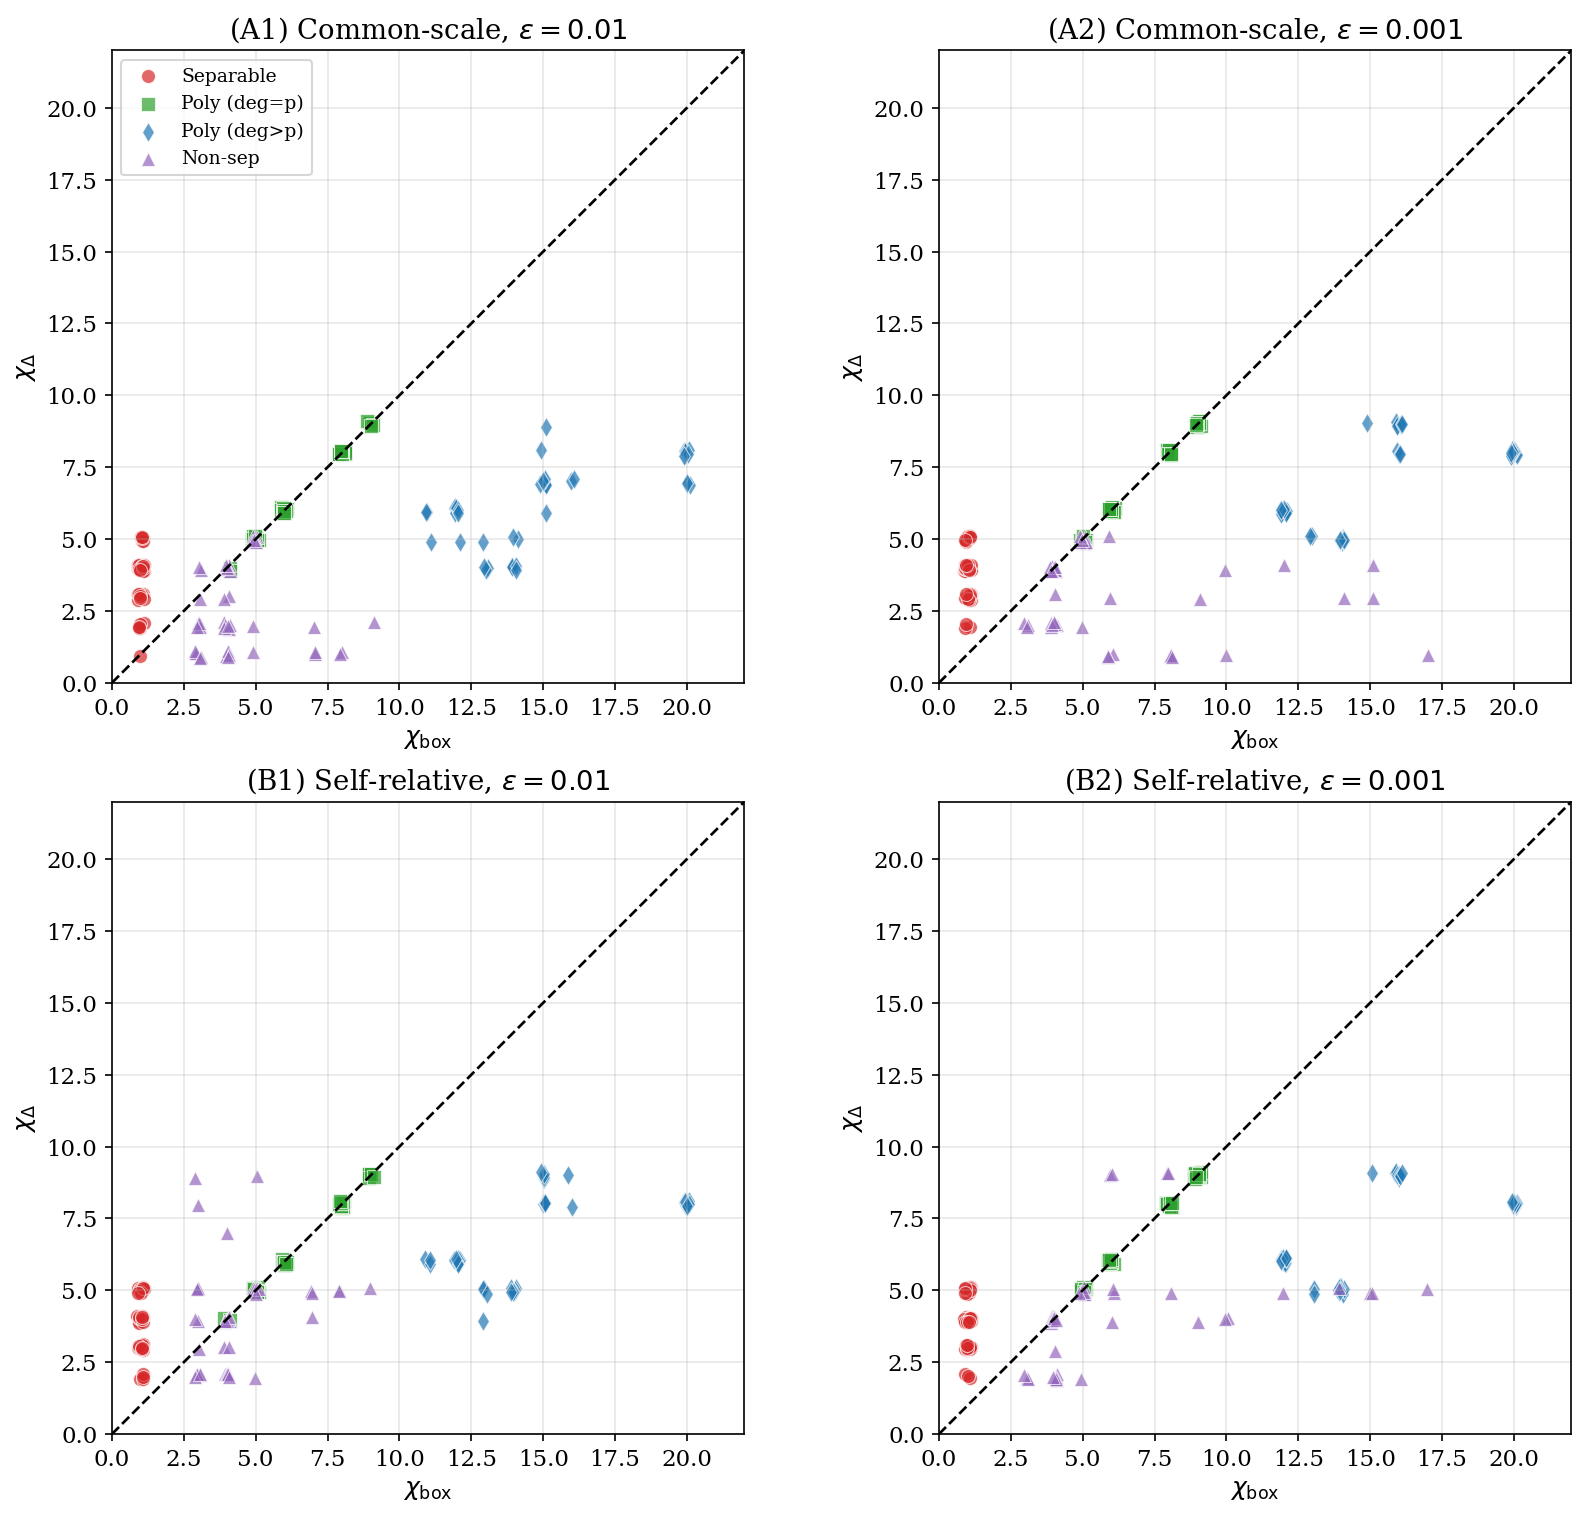

✓ Saved: figure_rank_scatter_2x2.pdf/png

TABLE: Summary of TT Rank Ratio ρ = χ_Δ / χ_box  [COMMON-SCALE (ref: ||A_box||)]

--- ε = 0.01 ---
Family                       n   median ρ              IQR  med χ_box    med χ_Δ
-----------------------------------------------------------------------------------------------
Separable                   48       4.00 [3.00, 4.00]         1          4
Poly (deg=p)                40       1.00 [1.00, 1.00]         7          7
Poly (deg>p)                40       0.40 [0.36, 0.47]        14          6
QuadraticForm               16       1.00 [1.00, 1.00]         4          4
Trig+Gauss                  32       0.37 [0.25, 0.67]         4          2
-----------------------------------------------------------------------------------------------

--- ε = 0.001 ---
Family                       n   median ρ              IQR  med χ_box    med χ_Δ
-----------------------------------------------------------------------------------------------
Separable 

In [3]:
#   - Prints two compact summary tables (one per metric) at eps=1e-2 and 1e- and plot is saved as png
# =============================================================================

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'figure.dpi': 150,
})


# =============================================================================
# Helpers
# =============================================================================

def keys_for_metric(eps: float, metric: str):
    """
    metric ∈ {"ref", "self"}
    ref  -> common-scale ranks: *_rank_ref@eps
    self -> self-relative ranks: *_rank_self@eps
    """
    if metric not in ("ref", "self"):
        raise ValueError("metric must be 'ref' or 'self'")
    key_box = f"box_rank_{metric}@{eps:g}"
    key_simp = f"simp_rank_{metric}@{eps:g}"
    return key_box, key_simp


def extract_by_family(results, eps, metric="ref", split_nonsep=False):
    """
    Extract data grouped by family using either:
      - metric="ref"  : common-scale ranks
      - metric="self" : self-relative ranks
    If split_nonsep=True, separates QuadraticForm from TrigPolySum+CorrGaussian.
    """
    key_box, key_simp = keys_for_metric(eps, metric)

    if split_nonsep:
        families = {
            'Separable':      {'color': '#d62728', 'marker': 'o', 'data': []},
            'Poly (deg=p)':   {'color': '#2ca02c', 'marker': 's', 'data': []},
            'Poly (deg>p)':   {'color': '#1f77b4', 'marker': 'd', 'data': []},
            'QuadraticForm':  {'color': '#9467bd', 'marker': '^', 'data': []},
            'Trig+Gauss':     {'color': '#ff7f0e', 'marker': 'v', 'data': []},
        }
    else:
        families = {
            'Separable':    {'color': '#d62728', 'marker': 'o', 'data': []},
            'Poly (deg=p)': {'color': '#2ca02c', 'marker': 's', 'data': []},
            'Poly (deg>p)': {'color': '#1f77b4', 'marker': 'd', 'data': []},
            'Non-sep':      {'color': '#9467bd', 'marker': '^', 'data': []},
        }

    for r in results:
        box_r = r.get(key_box)
        simp_r = r.get(key_simp)
        if box_r is None or simp_r is None:
            continue

        if r['family'] == 'separable':
            families['Separable']['data'].append((box_r, simp_r))
        elif r['family'] == 'poly':
            if r.get('poly_degree') == r['p']:
                families['Poly (deg=p)']['data'].append((box_r, simp_r))
            else:
                families['Poly (deg>p)']['data'].append((box_r, simp_r))
        elif r['family'] == 'nonsep':
            if split_nonsep:
                # exact matching
                if r['func'] == 'QuadraticForm':
                    families['QuadraticForm']['data'].append((box_r, simp_r))
                elif r['func'] in ('TrigPolySum', 'CorrGaussian'):
                    families['Trig+Gauss']['data'].append((box_r, simp_r))
            else:
                families['Non-sep']['data'].append((box_r, simp_r))

    return families


def get_global_max_rank(results, eps_list, metrics=("ref", "self")):
    """Global max rank across eps and metric choices, for consistent axes."""
    all_ranks = []
    for eps in eps_list:
        for metric in metrics:
            kbox, ksimp = keys_for_metric(eps, metric)
            for r in results:
                if r.get(kbox) is not None:
                    all_ranks.append(r[kbox])
                if r.get(ksimp) is not None:
                    all_ranks.append(r[ksimp])
    return max(all_ranks) + 2 if all_ranks else 25


def add_jitter(values, amount=0.12, seed=42):
    rng = np.random.default_rng(seed)
    return np.array(values) + rng.uniform(-amount, amount, size=len(values))


def scatter_panel(ax, fams, global_max_r, title, show_legend=False, base_seed=0):
    """Draw one scatter panel with diagonal, jitter, clipping."""
    seed_offset = 0
    for name, props in fams.items():
        if not props['data']:
            continue
        x_raw, y_raw = zip(*props['data'])
        x = add_jitter(x_raw, amount=0.12, seed=42 + base_seed + seed_offset)
        y = add_jitter(y_raw, amount=0.12, seed=142 + base_seed + seed_offset)  # different seed family
        seed_offset += 1

        # clip to bounds to avoid negative jitter artifacts
        x = np.clip(x, 0, global_max_r)
        y = np.clip(y, 0, global_max_r)

        ax.scatter(
            x, y,
            c=props['color'], marker=props['marker'],
            s=45, alpha=0.7, edgecolors='white', linewidth=0.5,
            label=name if show_legend else None
        )

    ax.plot([0, global_max_r], [0, global_max_r], 'k--', linewidth=1.3)
    ax.set_xlim(0, global_max_r)
    ax.set_ylim(0, global_max_r)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    ax.set_title(title)
    ax.set_xlabel(r'$\chi_{\mathrm{box}}$')
    ax.set_ylabel(r'$\chi_{\Delta}$')


def print_summary_table(results, eps_list, metric="ref", split_nonsep=True):
    """
    Print compact summary table for a metric:
      metric='ref'  -> common-scale
      metric='self' -> self-relative
    """
    metric_name = "COMMON-SCALE (ref: ||A_box||)" if metric == "ref" else "SELF-RELATIVE (self: ||A||)"
    print("\n" + "="*105)
    print(f"TABLE: Summary of TT Rank Ratio ρ = χ_Δ / χ_box  [{metric_name}]")
    print("="*105)

    for eps in eps_list:
        print(f"\n--- ε = {eps} ---")
        print(f"{'Family':<25} {'n':>4} {'median ρ':>10} {'IQR':>16} {'med χ_box':>10} {'med χ_Δ':>10}")
        print("-"*95)

        fams = extract_by_family(results, eps, metric=metric, split_nonsep=split_nonsep)

        for name, props in fams.items():
            data = props['data']
            if not data:
                continue
            x, y = zip(*data)
            x = np.array(x, dtype=float)
            y = np.array(y, dtype=float)
            ratios = y / x
            q1, q3 = np.percentile(ratios, [25, 75])
            print(f"{name:<25} {len(x):>4} {np.median(ratios):>10.2f} "
                  f"[{q1:.2f}, {q3:.2f}]{np.median(x):>10.0f} {np.median(y):>10.0f}")

        print("-"*95)


# =============================================================================
# FIGURE: 2x2 scatter grid (metric x epsilon)
# =============================================================================

eps_list = [0.01, 0.001]
global_max_r = get_global_max_rank(results, eps_list, metrics=("ref", "self"))

fig, axes = plt.subplots(2, 2, figsize=(11, 10), constrained_layout=True)

# Row 1: common-scale (ref)
for j, eps in enumerate(eps_list):
    fams = extract_by_family(results, eps, metric="ref", split_nonsep=False)
    scatter_panel(
        axes[0, j], fams, global_max_r,
        title=rf"(A{j+1}) Common-scale, $\varepsilon={eps}$",
        show_legend=(j == 0),
        base_seed=100*j
    )

# Row 2: self-relative
for j, eps in enumerate(eps_list):
    fams = extract_by_family(results, eps, metric="self", split_nonsep=False)
    scatter_panel(
        axes[1, j], fams, global_max_r,
        title=rf"(B{j+1}) Self-relative, $\varepsilon={eps}$",
        show_legend=False,
        base_seed=1000 + 100*j
    )

axes[0, 0].legend(loc="upper left", fontsize=9)
plt.savefig("figure_rank_scatter_2x2.pdf", bbox_inches="tight")
plt.savefig("figure_rank_scatter_2x2.png", dpi=300, bbox_inches="tight")
plt.show()

print("✓ Saved: figure_rank_scatter_2x2.pdf/png")


# =============================================================================
# TABLES: common-scale + self-relative
# =============================================================================
print_summary_table(results, eps_list=[0.01, 0.001], metric="ref", split_nonsep=True)
print_summary_table(results, eps_list=[0.01, 0.001], metric="self", split_nonsep=True)